# Pytorch를 활용한 MNIST 이미지 분류: FCN vs CNN 성능 비교



In [1]:
%pip install tqdm matplotlib pandas seaborn

Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install torchsummary

Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install torch torchvision torchaudio

Note: you may need to restart the kernel to use updated packages.


In [2]:
# 1. 라이브러리 임포트 및 환경 설정
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torchsummary import summary

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import random
import time

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"현재 사용 중인 디바이스: {device}")

현재 사용 중인 디바이스: cuda


# 1. 데이터 로드 및 전처리
Pytorch의 torchvision 통해 MNIST 데이터셋 다운로드
이미지 픽셀 값을 0~1 사이의 텐서로 변환한 뒤, 학습 안정성을 높이기 위해 평균 0.1307, 표준편차 0.3081을 적용하여 정규화 진행

100% 9.91M/9.91M [00:02<00:00, 3.79MB/s]
100% 28.9k/28.9k [00:00<00:00, 155kB/s]
100% 1.65M/1.65M [00:01<00:00, 1.29MB/s]
100% 4.54k/4.54k [00:00<00:00, 2.17MB/s]


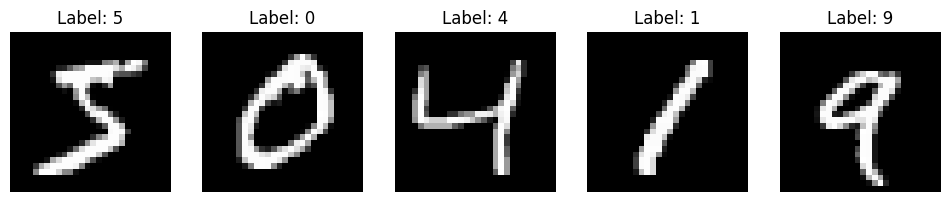

In [3]:
# 하이퍼파라미터 설정
BATCH_SIZE = 128 # 실무에서 자주 쓰이는 배치 사이즈로 변경
EPOCHS = 5
LEARNING_RATE = 0.001

# 이미지 전처리 파이프라인
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# 학습 및 테스트 데이터셋 로드
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader 설정
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# 데이터 확인 (샘플 이미지 시각화)
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(img.squeeze(), cmap='gray')
    axes[i].set_title(f"Label: {label}")
    axes[i].axis('off')
plt.show()

# 2. 모델 정의(Model Architecture)
- FCN (Fully-Connected Network): 2D 이미지를 1D로 길게 펼친(Flatten) 후 연속적인 선형 층(Linear Layer)을 통과시킵니다. 공간적 특성을 무시하기 때문에 파라미터 수가 급격히 많아집니다.
- CNN (Convolutional Neural Network): 이미지의 2D 공간적 특징(패턴, 엣지 등)을 유지하면서 필터(Filter)를 통해 학습합니다. 파라미터 수는 적지만 이미지 인식에 훨씬 효과적입니다.

In [6]:
# 1. 완전연결신경망 (FCN) 모델
class FCN_Model(nn.Module):
    def __init__(self):
        super(FCN_Model, self).__init__()
        self.flatten = nn.Flatten()
        # 28x28 픽셀 = 784개의 입력 피처
        self.fc_layers = nn.Sequential(
            nn.Linear(28 * 28, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10) # 10개의 클래스(0~9)로 출력
        )

    def forward(self, x):
        x = self.flatten(x)
        return self.fc_layers(x)

# 2. 합성곱신경망 (CNN) 모델
class CNN_Model(nn.Module):
    def __init__(self):
        super(CNN_Model, self).__init__()
        # 합성곱 계층 (Feature Extraction)
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        
        # 완전연결 계층 (Classification)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.drop = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = self.drop(x)
        return self.fc2(x)

# 모델 구조 및 파라미터 수 확인
print("--- FCN 구조 ---")
summary(FCN_Model().to(device), (1, 28, 28))
print("\n--- CNN 구조 ---")
summary(CNN_Model().to(device), (1, 28, 28))

--- FCN 구조 ---
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                  [-1, 784]               0
            Linear-2                  [-1, 256]         200,960
              ReLU-3                  [-1, 256]               0
           Dropout-4                  [-1, 256]               0
            Linear-5                  [-1, 128]          32,896
              ReLU-6                  [-1, 128]               0
           Dropout-7                  [-1, 128]               0
            Linear-8                   [-1, 10]           1,290
Total params: 235,146
Trainable params: 235,146
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.90
Estimated Total Size (MB): 0.91
----------------------------------------------------------------

--- CNN 구조 ---
-----------

# 3. 모델 학습 및 평가 파이프라인
공정한 비교를 위해 두 모델에 동일한 학습 루프, 손실 함수(CrossEntropyLoss), 옵티마이저(Adam)를 적용합니다.

In [7]:
def train_and_evaluate(model, model_name):
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
    start_time = time.time()
    
    # 학습 루프
    for epoch in range(1, EPOCHS + 1):
        model.train()
        train_loss = 0.0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            
        print(f"[{model_name}] Epoch {epoch}/{EPOCHS} - Loss: {train_loss/len(train_loader):.4f}")
        
    train_duration = time.time() - start_time
    
    # 평가 루프
    model.eval()
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            
    accuracy = 100 * correct / total
    
    # 파라미터 수 계산
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    
    return {
        "Model": model_name,
        "Parameters": total_params,
        "Accuracy (%)": round(accuracy, 2),
        "Training Time (s)": round(train_duration, 2),
        "Trained_Model": model
    }

# 실행
print(">>> FCN 학습 시작")
fcn_results = train_and_evaluate(FCN_Model(), "FCN")

print("\n>>> CNN 학습 시작")
cnn_results = train_and_evaluate(CNN_Model(), "CNN")

>>> FCN 학습 시작
[FCN] Epoch 1/5 - Loss: 0.4546
[FCN] Epoch 2/5 - Loss: 0.2290
[FCN] Epoch 3/5 - Loss: 0.1865
[FCN] Epoch 4/5 - Loss: 0.1654
[FCN] Epoch 5/5 - Loss: 0.1509

>>> CNN 학습 시작
[CNN] Epoch 1/5 - Loss: 0.3398
[CNN] Epoch 2/5 - Loss: 0.1065
[CNN] Epoch 3/5 - Loss: 0.0810
[CNN] Epoch 4/5 - Loss: 0.0681
[CNN] Epoch 5/5 - Loss: 0.0598


# 4. 최종 결과 비교
FCN과 CNN의 성능을 표로 요약하여 비교합니다. CNN이 파라미터 수는 훨씬 적으면서도 높은 정확도를 달성하는 것을 볼 수 있습니다. 이는 이미지 데이터의 지역적 특성을 필터를 통해 효율적으로 뽑아내는 CNN의 강점을 잘 보여줍니다.

,Model,Parameters,Accuracy (%),Training Time (s)
0,FCN,235146,97.35,42.10
1,CNN,206922,99.01,44.07


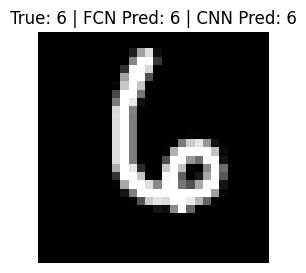

In [8]:
# 결과 정리 및 시각화
results_df = pd.DataFrame([
    {k: v for k, v in fcn_results.items() if k != "Trained_Model"},
    {k: v for k, v in cnn_results.items() if k != "Trained_Model"}
])

display(results_df)

# 예측 테스트 (잘못 분류하기 쉬운 샘플 시각화)
sample_idx = random.randint(0, len(test_dataset))
img, label = test_dataset[sample_idx]

with torch.no_grad():
    fcn_pred = fcn_results['Trained_Model'](img.unsqueeze(0).to(device)).argmax(dim=1).item()
    cnn_pred = cnn_results['Trained_Model'](img.unsqueeze(0).to(device)).argmax(dim=1).item()

plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"True: {label} | FCN Pred: {fcn_pred} | CNN Pred: {cnn_pred}")
plt.axis('off')
plt.show()